In [23]:
import zarr
import numpy as np
import matplotlib.pyplot as plt

zarr_path = r"/Users/sasakinozomu/code/MTCargoSim/analysis/data/cargo_msd_seeds.zarr"
data = zarr.open_array(zarr_path, mode='r')
print(f"Data shape: {data.shape}")

Data shape: (75, 10000)


[(1.0, 10000.0),
 (0.1, 100000000.0),
 None,
 None,
 Text(0.5, 0, 'lag time $\\Delta \\hat{t}$'),
 Text(0, 0.5, 'MSD $\\langle \\Delta {r}^2 \\rangle$')]

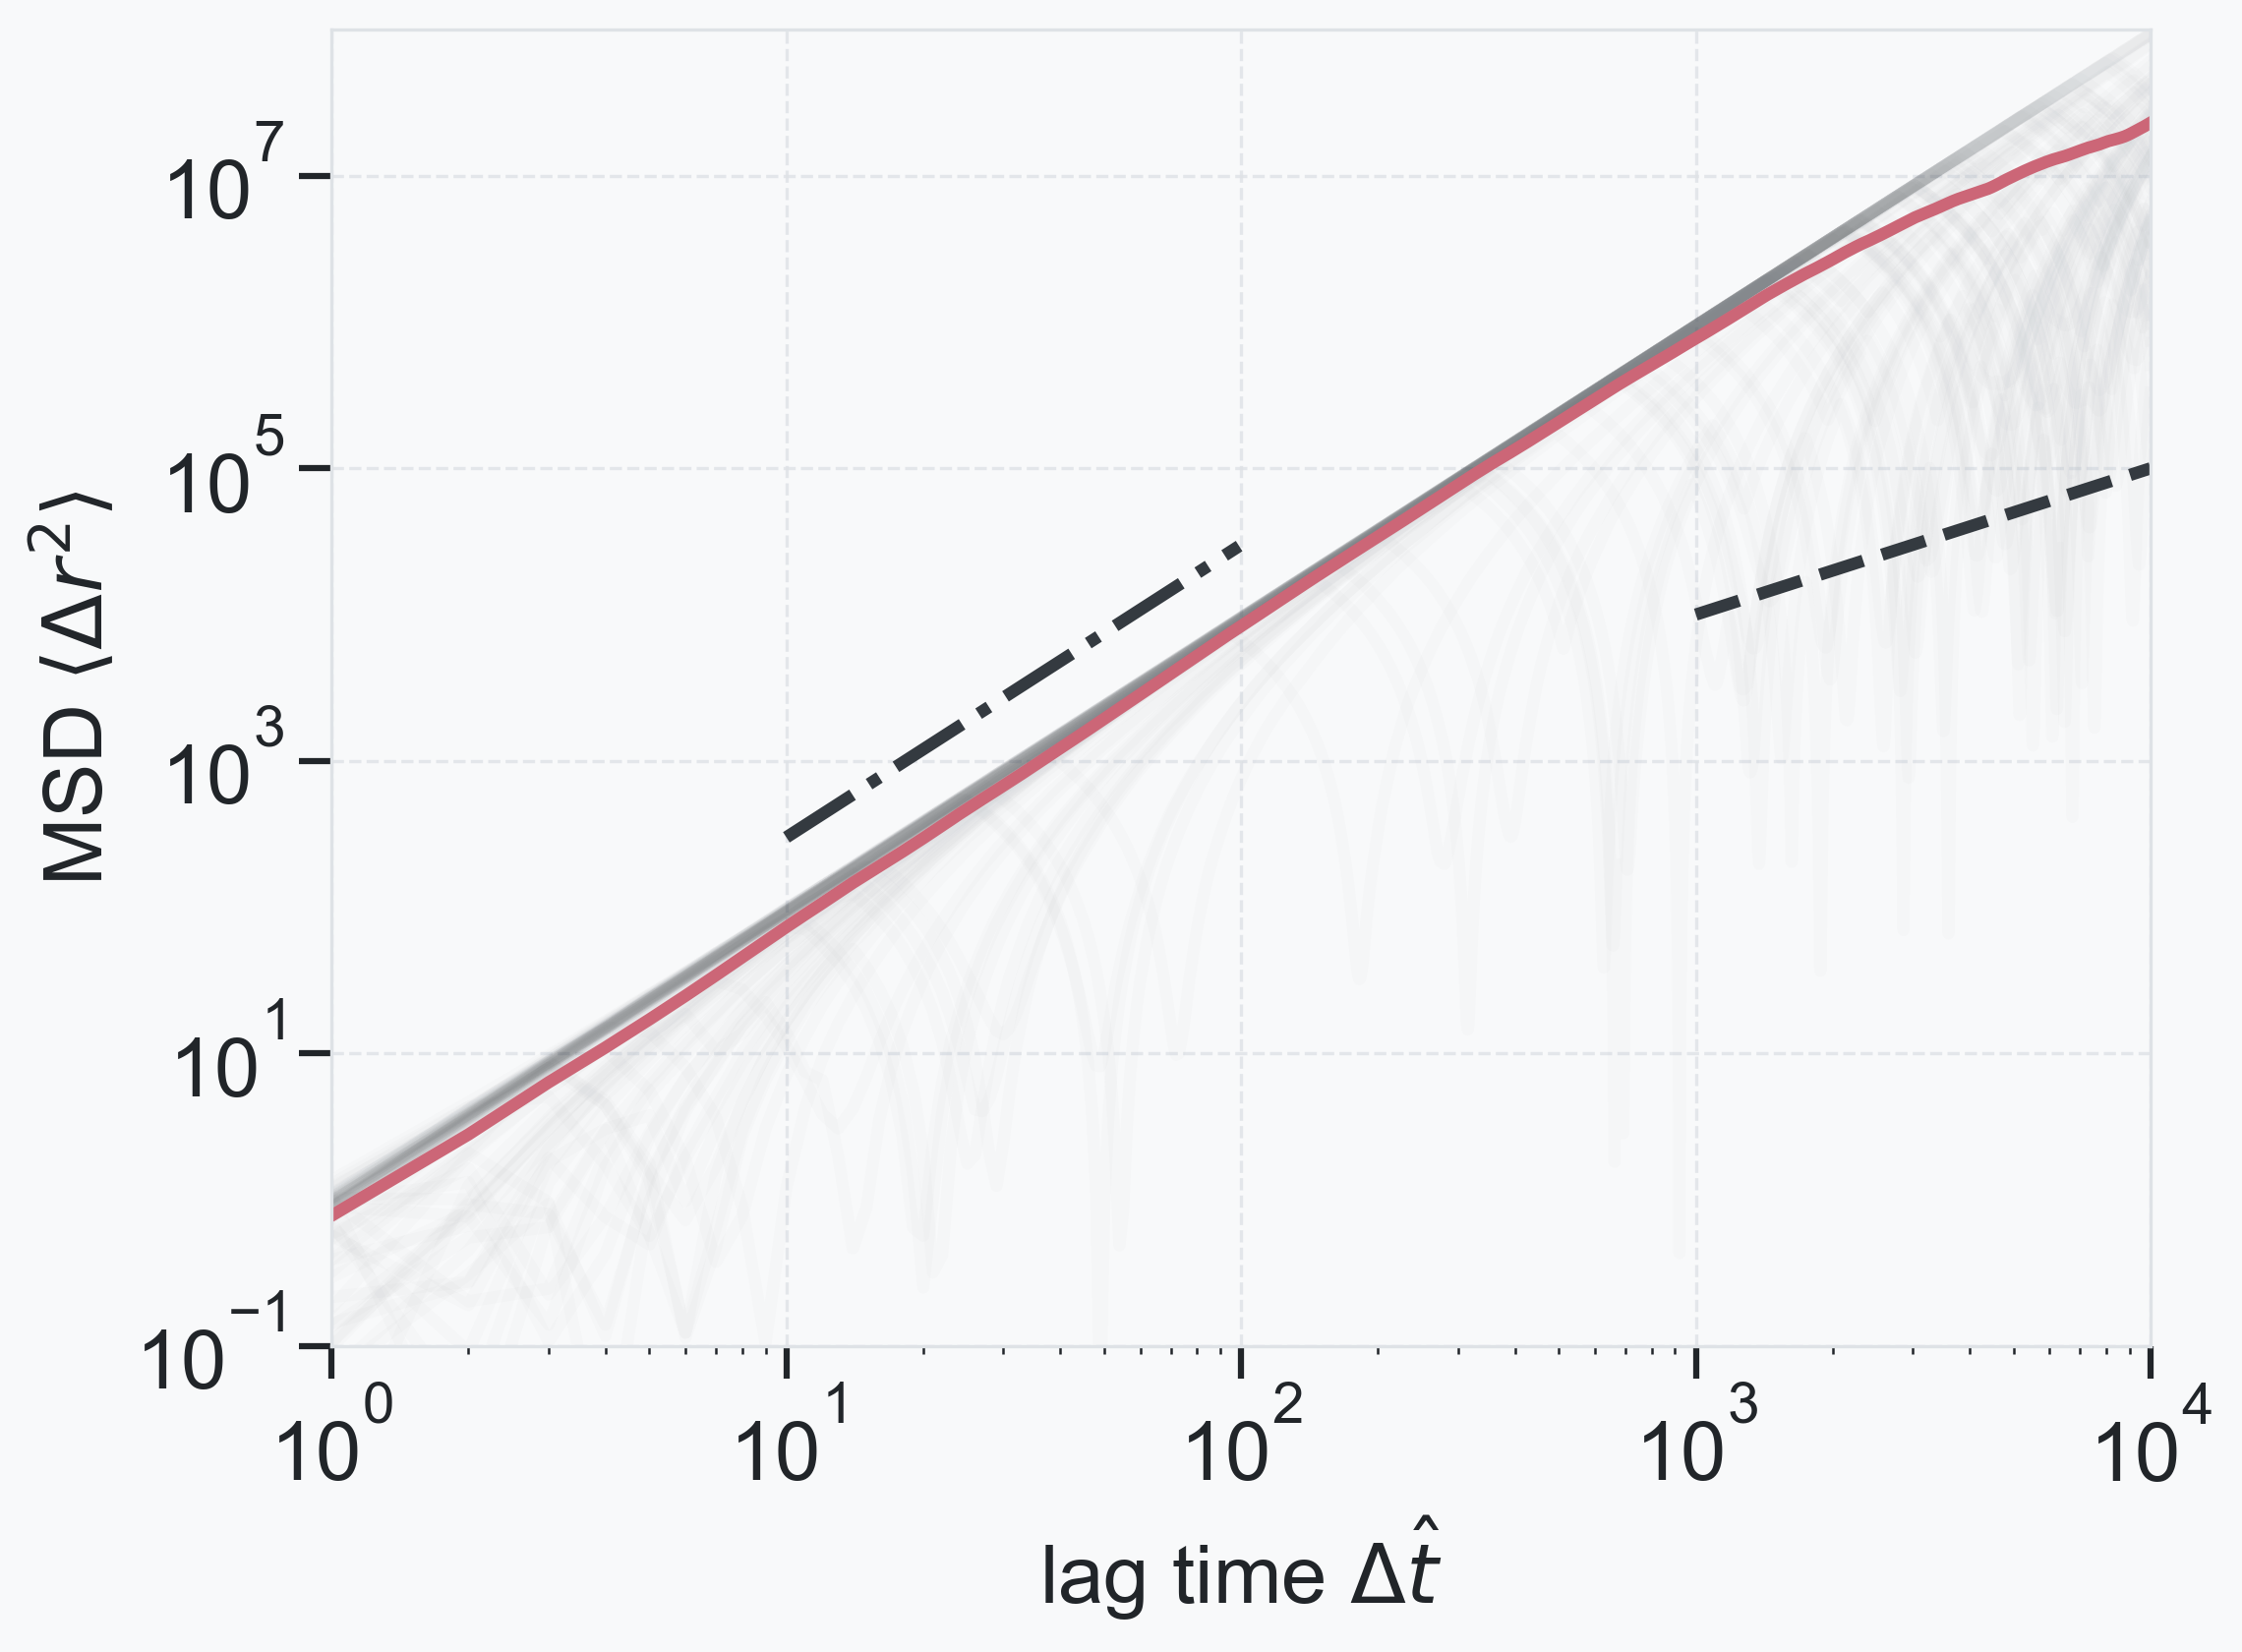

In [60]:
plt.style.use('../../my_style.mplstyle')

len = data.shape[1]
t = np.arange(len)
fig, ax = plt.subplots()

for i in range(data.shape[0]):
    ax.plot(t, data[i, :], alpha=0.01, color="#343A40")

ax.plot(t, np.mean(data, axis=0), label='Ensemble', lw=3)

t1 = np.arange(1e3, 1e4)
t2 = np.arange(1e1, 1e2)

y1 = 1.0e1 * t1 ** 1.0
y2 = 3.0e-0 * t2 ** 2.0

ax.plot(t1, y1, c = '#343A40', linestyle = '--')
ax.plot(t2, y2, c = '#343A40', linestyle = '-.')

ax.set(
    xlim=(1e0, 1e4),
    ylim=(1e-1, 1e8),
    xscale='log',
    yscale='log',
    xlabel='lag time $\Delta \hat{t}$',
    ylabel='MSD $\\langle \\Delta {r}^2 \\rangle$'
    )